In [1]:
import keras
from keras import layers, models, datasets

# MNIST CNN Implementation
(mnist_train_img, mnist_train_lbl), (mnist_test_img, mnist_test_lbl) = datasets.mnist.load_data()
mnist_train_img = mnist_train_img.reshape((60000, 28, 28, 1)).astype('float32') / 255
mnist_test_img = mnist_test_img.reshape((10000, 28, 28, 1)).astype('float32') / 255

mnist_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

mnist_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_mnist = mnist_model.fit(mnist_train_img, mnist_train_lbl, epochs=10, batch_size=64, validation_data=(mnist_test_img, mnist_test_lbl))

# MNIST Evaluation
test_loss, test_acc = mnist_model.evaluate(mnist_test_img, mnist_test_lbl, verbose=0)
print(f"MNIST Final Test Accuracy: {test_acc:.4f}")

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9520 - loss: 0.1626 - val_accuracy: 0.9845 - val_loss: 0.0475
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9853 - loss: 0.0495 - val_accuracy: 0.9858 - val_loss: 0.0415
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9890 - loss: 0.0351 - val_accuracy: 0.9896 - val_loss: 0.0313
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9917 - loss: 0.0265 - val_accuracy: 0.9907 - val_loss: 0.0288
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9933 - loss: 0.0206 - val_accuracy: 0.9908 - val_loss: 0.0320
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9945 - loss: 0.0159 - val_accuracy: 0.9876 - val_loss: 0.0402
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9962 - loss: 0.0119 - val_accuracy: 0.9887 - val_loss: 0.0400
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9963 - loss: 0.0112 - 

In [2]:
mnist_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         200,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 660,704 (2.52 MB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 440,470 (1.68 MB)

In [3]:
import keras
from keras import layers, models, datasets

# CIFAR CNN Implementation
(cifar_train_img, cifar_train_lbl), (cifar_test_img, cifar_test_lbl) = datasets.cifar100.load_data()
cifar_train_img = cifar_train_img.astype('float32') / 255
cifar_test_img = cifar_test_img.astype('float32') / 255

cifar_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(100, activation='softmax')
])

cifar_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cifar = cifar_model.fit(cifar_train_img, cifar_train_lbl, epochs=10, batch_size=64, validation_data=(cifar_test_img, cifar_test_lbl))
test_loss, test_acc = cifar_model.evaluate(cifar_test_img, cifar_test_lbl, verbose=0)
print(f"CIFAR-100 Final Test Accuracy: {test_acc:.4f}")

C:\Users\Insomnyac\anaconda3\envs\ml-lab\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.1616 - loss: 3.5942 - val_accuracy: 0.2697 - val_loss: 2.9828
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 117ms/step - accuracy: 0.3319 - loss: 2.6530 - val_accuracy: 0.3484 - val_loss: 2.5900
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step - accuracy: 0.4329 - loss: 2.1802 - val_accuracy: 0.3893 - val_loss: 2.4001
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 120ms/step - accuracy: 0.5143 - loss: 1.8146 - val_accuracy: 0.4116 - val_loss: 2.3791
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.5973 - loss: 1.4685 - val_accuracy: 0.4218 - val_loss: 2.4572
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 127ms/step - accuracy: 0.6795 - loss: 1.1311 - val_accuracy: 0.3988 - val_loss: 2.6909
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 122ms/step - accuracy: 0.7582 - loss: 0.8277 - val_accuracy: 0.3928 - val_loss: 3.0964
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 138ms/step - accuracy: 0.8242 - loss:

In [8]:
cifar_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,707,054 (25.59 MB)

 Trainable params: 2,235,684 (8.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,471,370 (17.06 MB)

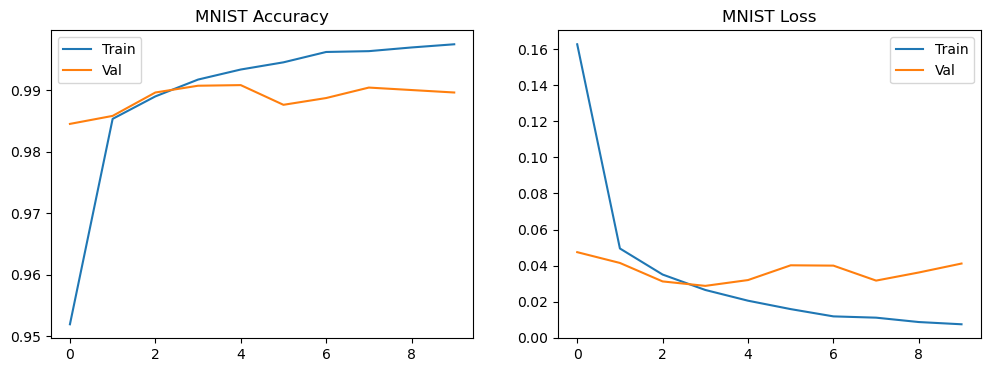

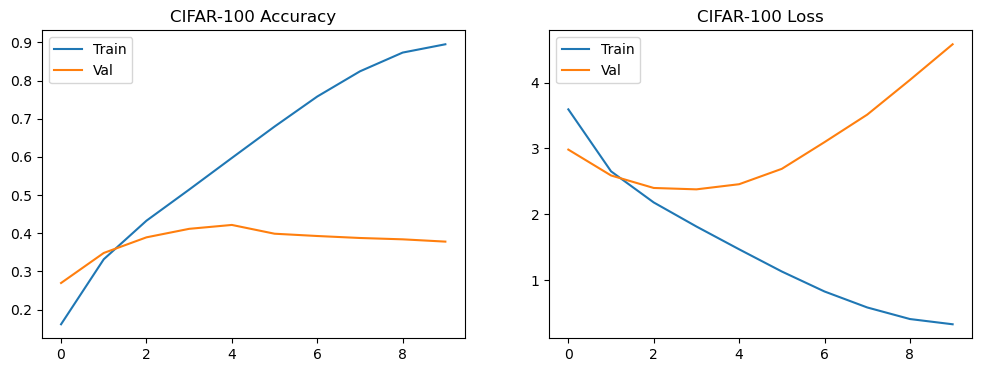

In [5]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{title} Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

plot_history(history_mnist, "MNIST")
plot_history(history_cifar, "CIFAR-100")

In [6]:
# CNNs achieve significantly higher accuracy than ANNs because they utilize filters and pooling for location invariance and reduced computation, whereas ANNs are hindered by excessive parameters and extreme sensitivity to an object's position in an image.

In [7]:
# MNIST CNN Architecture Breakdown
# This model is designed to recognize simple grayscale digit patterns.  
# Total Functional Layers: 7 (Excluding the Input layer).  
# Convolutional Layers: 2 layers using 3x3 filters to detect lines and "loopy circle" patterns.  
# Pooling Layers: 2 Max Pooling layers used to reduce dimensions and ensure the model is tolerant toward distortions.  
# Classification Layers: 3 layers (1 Flatten layer to convert 3D maps to 1D, and 2 Dense layers to make the final prediction). 
# Activation: Uses ReLU for hidden layers to speed up computation and Softmax for the output to provide probabilities. 

In [8]:
# CIFAR-100 CNN Architecture Breakdown
# This model is deeper to handle the high variety in multi-channel color images.  
# Total Functional Layers: 8 (Excluding the Input layer).  
# Convolutional Layers: 3 layers; it uses a "double convolution" block (two consecutive Conv layers) to capture more complex color features.  
# Pooling Layers: 2 Max Pooling layers to reduce computation and prevent overfitting by making the model location invariant. 
# Classification Layers: 3 layers (1 Flatten layer to distill features and 2 Dense layers for the 100-class decision).  
# Activation: Relies on ReLU nonlinearity to handle complex image characteristics effectively. 

In [9]:
# Comparison with Fully Connected Networks (ANN)
# Weight Efficiency: ANNs require a weight for every pixel-to-neuron connection, leading to millions of parameters, whereas CNNs use parameter sharing to reuse filters across the image. 
# Spatial Intelligence: ANNs treat local pixels the same as pixels far apart, while CNNs use convolution to specifically identify local patterns like edges or shapes. 
# Location Invariance: An ANN is highly sensitive to the position of an object, but a CNN can detect a feature (like an "eye" or "digit loop") anywhere in the frame.  
# Computational Load: For large images, an ANN would require billions or trillions of weights, while CNNs use stride and pooling to reduce dimensions and speed up training.  